<a href="https://colab.research.google.com/github/deepan98raj-dotcom/Assessment/blob/main/Linear%2C_Logistic%2C_Knn%2C_Svm%2C_Decision_Tree_%26_Pruning_Assign_on_24_7_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Logistic Regression

Instructions : Take One Dataset and Implement the SOP for all the ML algorithms we covered by learning through the materials i shared and other online resources.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import io

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

columns = ['age','workclass','fnlwgt','education','education-num','marital-status','occupation','relationship',
           'race','sex','capital-gain','capital-loss','hours-per-week','native-country','income']

url = '/content/adult.data'
df = pd.read_csv(url, sep=r',\s*', names=columns, engine='python')
print("Dataset Shape:", df.shape)
print(df.head())


#Additional Information in UCI
# A set of reasonably clean records was extracted
# using the following conditions: ((AAGE>16) && (AGI>100) && (AFNLWGT>1)&& (HRSWK>0))

print('____' * 20)
# 1. Apply filtering conditions
df_filtered = df[(df['age'] > 16) & (df['fnlwgt'] > 1) & (df['hours-per-week'] > 0)]

print("Shape of filtered dataset:", df_filtered.shape)
print(df_filtered.head())

print('____' * 20)
# 2. Apply missing values
print("\nMissing values:\n", df.isnull().sum())

Dataset Shape: (32561, 15)
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0

In [ ]:
# 3. Define features (X) and target (y)
X = df_filtered.drop('income', axis=1)
y = df_filtered['income']

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Encode the target variable 'income' to numerical values
# Assuming '<=50K' is 0 and '>50K' is 1
y = y.map({'<=50K': 0, '>50K': 1})

print("Shape of feature matrix X:", X.shape)
print("Shape of target vector y:", y.shape)

print("\nFirst 5 rows of X (after one-hot encoding):")
display(X.head())

print("\nFirst 5 values of y (after encoding):")
display(y.head())

Shape of feature matrix X: (32561, 100)
Shape of target vector y: (32561,)

First 5 rows of X (after one-hot encoding):


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,77516,13,2174,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38,215646,9,0,0,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,53,234721,7,0,0,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,28,338409,13,0,0,40,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False



First 5 values of y (after encoding):


,income
0,0
1,0
2,0
3,0
4,0


In [ ]:
# 4. Split into Training and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 5. Initialize and Train the Model
model = LogisticRegression(solver='liblinear') # Added solver for convergence
model.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

In [ ]:
# 6. Evaluate the Model Make predictions on the test set
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7927222478120681

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.97      0.88      4918
           1       0.72      0.25      0.37      1595

    accuracy                           0.79      6513
   macro avg       0.76      0.61      0.62      6513
weighted avg       0.78      0.79      0.75      6513


Confusion Matrix:
 [[4761  157]
 [1193  402]]


In [ ]:
# 7. Extract the Model parameters (Log-odds coefficients)
slope = model.coef_[0][0]
intercept = model.intercept_[0]
print(f"\nModel Log-odds Equation: ln(p/(1-p)) = {intercept:.2f} + {slope:.2f} * Age")


Model Log-odds Equation: ln(p/(1-p)) = -0.00 + -0.01 * Age



Accuracy Score: 0.7927

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.97      0.88      4918
           1       0.72      0.25      0.37      1595

    accuracy                           0.79      6513
   macro avg       0.76      0.61      0.62      6513
weighted avg       0.78      0.79      0.75      6513



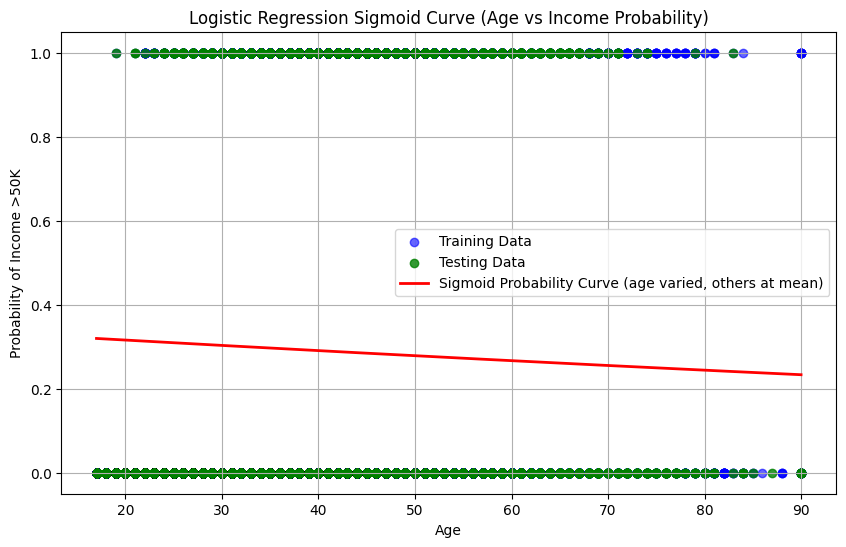

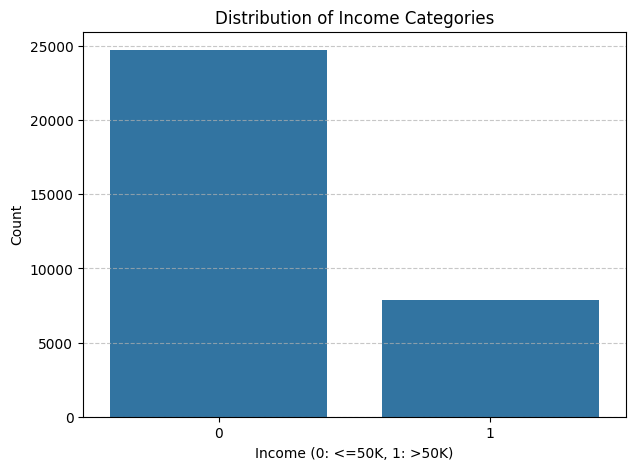

In [ ]:
# 8. Predict and Evaluate
y_pred = model.predict(X_test)
# Logistic regression can also output probabilities instead of just 0 or 1 class labels
y_prob = model.predict_proba(X_test)[:, 1]

print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 9. Plot the Results (Plotting the Sigmoid Curve for 'age')
plt.figure(figsize=(10, 6))

# Plot actual data points using 'age' as the x-axis feature
plt.scatter(X_train['age'], y_train, color='blue', alpha=0.6, label='Training Data')
plt.scatter(X_test['age'], y_test, color='green', alpha=0.8, label='Testing Data')

# Generate a smooth curve of age values for plotting the Sigmoid
# We'll use the 'age' feature for the x-axis and keep other features at their mean for prediction
age_min = X['age'].min()
age_max = X['age'].max()
X_smooth_age = np.linspace(age_min, age_max, 300).reshape(-1, 1)

# Create a DataFrame for prediction, filling other features with their mean from X_train
X_plot = pd.DataFrame(X_train.mean().values.reshape(1, -1), columns=X_train.columns)
X_plot = X_plot.loc[X_plot.index.repeat(X_smooth_age.shape[0])].reset_index(drop=True)
X_plot['age'] = X_smooth_age

# Predict probabilities using the model
y_smooth_prob = model.predict_proba(X_plot)[:, 1]

plt.plot(X_smooth_age, y_smooth_prob, color='red', linewidth=2, label='Sigmoid Probability Curve (age varied, others at mean)')

plt.title('Logistic Regression Sigmoid Curve (Age vs Income Probability)')
plt.xlabel('Age')
plt.ylabel('Probability of Income >50K')
plt.legend()
plt.grid(True)
plt.show()

# Plot the distribution of the target variable 'income'
plt.figure(figsize=(7, 5))
sns.countplot(x=y)
plt.title('Distribution of Income Categories')
plt.xlabel('Income (0: <=50K, 1: >50K)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Logistic Regression

Afterwards , Take an another dataset and Work out on the ML algorithms and build an Model from Analysis to Evaluation . Exclude the matplotlib and Seaborn Visualisation (DO IT IF YOU ARE INTERESTED) include all the SOP we discussed in class on your own without referring any resources .

In [ ]:


heading = ['school','sex','age','address','famsize','Pstatus','Medu','Fedu','Mjob','Fjob','reason','guardian','traveltime',
           'studytime','failures','schoolsup','famsup','paid','activities','nursery','higher','internet','romantic','famrel',
           'freetime','goout','Dalc','Walc','health','absences','G1','G2','G3']


# Read 'student-por.csv','student-mat.csv' into a DataFrame
df_por = pd.read_csv('/content/student-por.csv', sep=';', names=heading, skiprows=1)
df_mat = pd.read_csv('/content/student-mat.csv', sep=';', names=heading, skiprows=1)
print("Shape of df_por:", df_por.shape)
print("First 5 rows of df_por:")
display(df_por.head())
print("Shape of df_mat:", df_mat.shape)
print("First 5 rows of df_mat:")
display(df_mat.head())


Shape of df_por: (649, 33)
First 5 rows of df_por:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


Shape of df_mat: (395, 33)
First 5 rows of df_mat:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
common_cols = ['school','sex','age','address','famsize','Pstatus','Medu','Fedu','Mjob','Fjob','reason','guardian','traveltime',
           'studytime','failures','schoolsup','famsup','paid','activities','nursery','higher','internet','romantic','famrel',
           'freetime','goout','Dalc','Walc','health','absences']

df_merged = pd.merge(df_por, df_mat, on=common_cols, how='inner', suffixes=('_por', '_mat'))

print("Shape of df_merged:", df_merged.shape)
print("First 5 rows of df_merged:")
display(df_merged.head())

Shape of df_merged: (39, 36)
First 5 rows of df_merged:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Dalc,Walc,health,absences,G1_por,G2_por,G3_por,G1_mat,G2_mat,G3_mat
0,GP,M,16,U,LE3,T,2,2,other,other,...,1,1,3,0,13,12,13,12,12,11
1,GP,M,15,U,GT3,A,2,2,other,other,...,1,1,3,0,14,14,15,14,16,16
2,GP,M,15,U,GT3,T,4,3,teacher,other,...,1,1,1,0,12,13,14,13,14,15
3,GP,M,15,U,GT3,T,4,4,health,health,...,1,1,5,0,11,12,12,12,15,15
4,GP,M,15,U,GT3,T,4,4,health,services,...,3,4,5,0,10,11,11,9,11,12


In [ ]:

# Define the target variable: pass/fail in G3_mat
# Assuming a passing grade is >= 10 (out of 20)
df_merged['pass_mat'] = (df_merged['G3_mat'] >= 10).astype(int)

print("\nDistribution of the new target variable 'pass_mat':")
display(df_merged['pass_mat'].value_counts())


Distribution of the new target variable 'pass_mat':


,count
pass_mat,
1,32
0,7


In [ ]:
# Define features (X) and target (y)
# Drop original grade columns and the newly created target from features
features_to_drop = [
    'G1_mat', 'G2_mat', 'G3_mat', 'G1_por', 'G2_por', 'G3_por', 'pass_mat'
]

X = df_merged.drop(columns=features_to_drop, errors='ignore')
y = df_merged['pass_mat']

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Shape of feature matrix X:", X.shape)
print("Shape of target vector y:", y.shape)

print("\nFirst 5 rows of X:")
display(X.head())
print("\nFirst 5 values of y:")
display(y.head())

Shape of feature matrix X: (39, 38)
Shape of target vector y: (39,)

First 5 rows of X:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,reason_reputation,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,internet_yes,romantic_yes
0,16,2,2,1,2,0,4,4,4,1,...,False,True,False,False,False,False,False,True,True,False
1,15,2,2,1,3,0,4,5,2,1,...,False,False,True,False,True,False,False,True,True,True
2,15,4,3,1,2,0,4,4,1,1,...,True,True,False,False,False,False,False,True,True,False
3,15,4,4,1,1,0,5,4,2,1,...,False,False,False,False,True,True,False,True,True,False
4,15,4,4,1,2,0,5,4,2,3,...,False,True,False,False,True,True,False,False,True,False



First 5 values of y:


,pass_mat
0,1
1,1
2,1
3,1
4,1


In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (31, 38)
X_test shape: (8, 38)
y_train shape: (31,)
y_test shape: (8,)


In [ ]:
# Initialize and train a Logistic Regression model
# Using 'liblinear' solver for binary classification on potentially smaller datasets
model_student = LogisticRegression(solver='liblinear', random_state=42)
model_student.fit(X_train, y_train)

print("Logistic Regression model trained.")

Logistic Regression model trained.


In [ ]:
# Make predictions on the test set
y_pred_student = model_student.predict(X_test)

# Evaluate the model
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_student):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_student))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_student))


--- Model Evaluation ---
Accuracy: 0.6250

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.83      0.71      0.77         7

    accuracy                           0.62         8
   macro avg       0.42      0.36      0.38         8
weighted avg       0.73      0.62      0.67         8


Confusion Matrix:
 [[0 1]
 [2 5]]


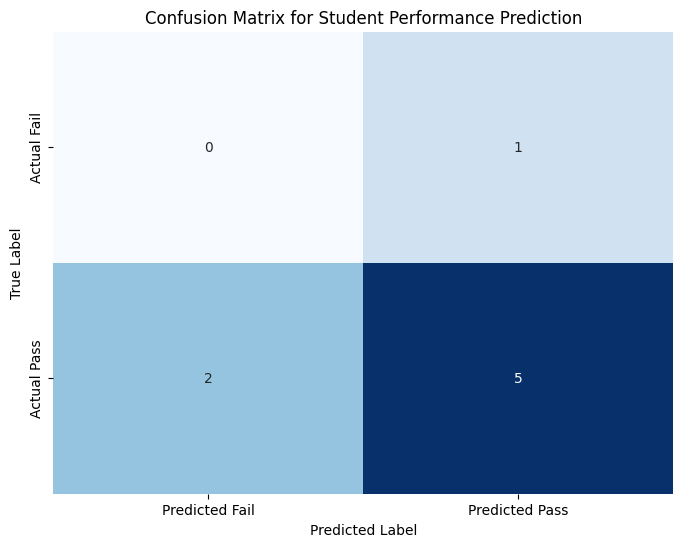

In [ ]:
cm = confusion_matrix(y_test, y_pred_student)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Fail', 'Predicted Pass'],
            yticklabels=['Actual Fail', 'Actual Pass'])
plt.title('Confusion Matrix for Student Performance Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


Top 10 Most Important Features (absolute coefficients):



,Feature,Coefficient,Absolute_Coefficient
8,goout,-1.061162,1.061162
7,freetime,0.741518,0.741518
4,studytime,0.713362,0.713362
29,guardian_mother,0.615748,0.615748
2,Fedu,0.608697,0.608697
34,activities_yes,-0.572649,0.572649
26,reason_home,0.534024,0.534024
1,Medu,0.486827,0.486827
10,Walc,0.465486,0.465486
30,guardian_other,-0.449096,0.449096


/tmp/ipykernel_913/3882255847.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Absolute_Coefficient', y='Feature', data=feature_importance.head(15), palette='viridis', hue=None, legend=False)


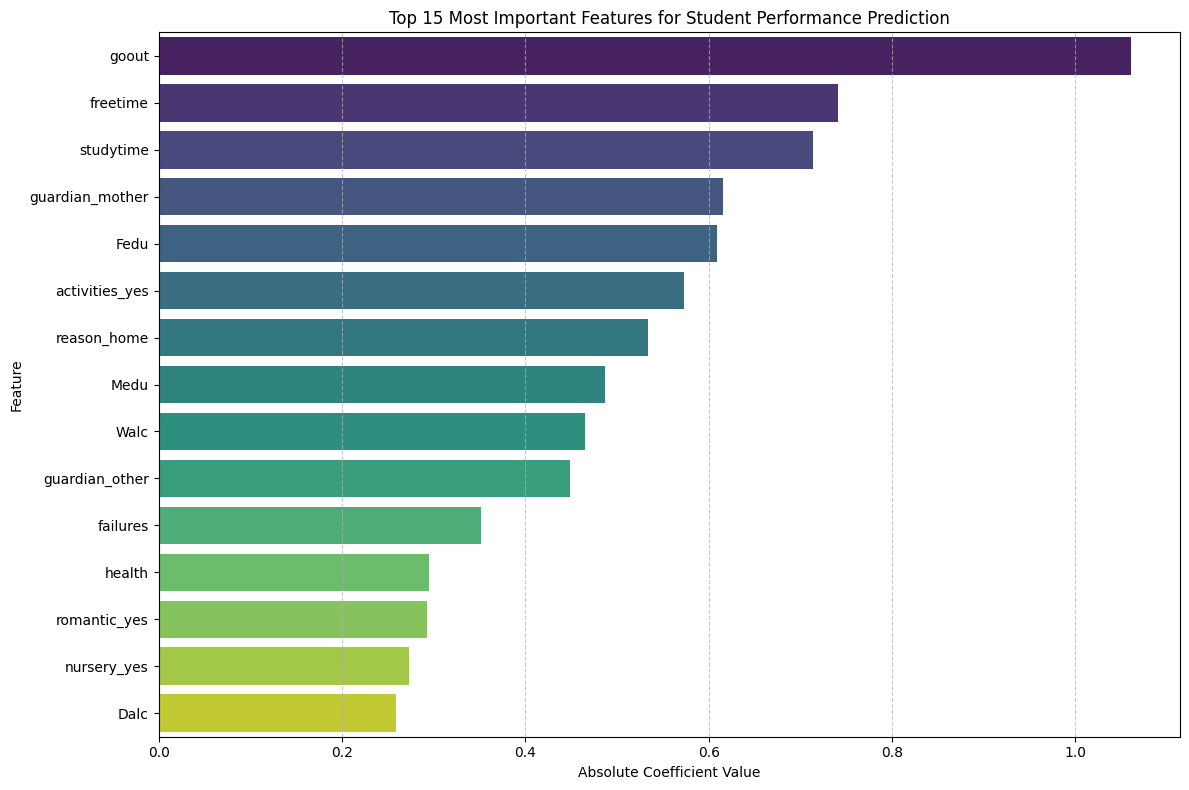

In [ ]:

# Get the absolute coefficients from the trained model
coefficients = model_student.coef_[0]
absolute_coefficients = np.abs(coefficients)

# Re-create the X dataframe for the student performance data to get the correct feature names
# This replicates the steps from cell 1e8062e4
features_to_drop_student = [
    'G1_mat', 'G2_mat', 'G3_mat', 'G1_por', 'G2_por', 'G3_por', 'pass_mat'
]
# Assuming df_merged is still available and correct from cell 140ec6ed
X_student_for_features = df_merged.drop(columns=features_to_drop_student, errors='ignore')
categorical_cols_student = X_student_for_features.select_dtypes(include='object').columns
X_student_encoded_for_features = pd.get_dummies(X_student_for_features, columns=categorical_cols_student, drop_first=True)
feature_names = X_student_encoded_for_features.columns

# Create a DataFrame for better visualization
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Coefficient': absolute_coefficients
})

# Sort by absolute coefficient value to find the most important features
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

print("\nTop 10 Most Important Features (absolute coefficients):\n")
display(feature_importance.head(10))

# Plotting the feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Absolute_Coefficient', y='Feature', data=feature_importance.head(15), palette='viridis', hue=None, legend=False)
plt.title('Top 15 Most Important Features for Student Performance Prediction')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Linear Regression Model

Whenever a dataset is selected for model building  , Include Business Problem, Objective , and Solution in documentation . It is for your better understanding of the work flow .


  A)     Build an Model Using Linear regression , Perform all the analysis      including MSE,r-square ,OLS .  Identify whether can we build confusion matrix and corelation matrix for this algorithm .


     X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28
(768, 10)

First 5 rows of X:


,X1
0,0.98
1,0.98
2,0.98
3,0.98
4,0.90



First 5 values of y:


,Y1
0,15.55
1,15.55
2,15.55
3,15.55
4,20.84


Training set size: 614
Testing set size: 154
________________________________________________________________________________
Model Intercept: -23.56
Model Coefficient: 60.02
________________________________________________________________________________
Correlation between X1 and Y1: 0.62
________________________________________________________________________________
                            OLS Regression Results                            
Dep. Variable:                     Y1   R-squared:                       0.396
Model:                            OLS   Adj. R-squared:                  0.395
Method:                 Least Squares   F-statistic:                     401.3
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           4.99e-69
Time:                        10:38:02   Log-Likelihood:                -2133.0
No. Observations:                 614   AIC:                             4270.
Df Residuals:                     612   BIC:                             4

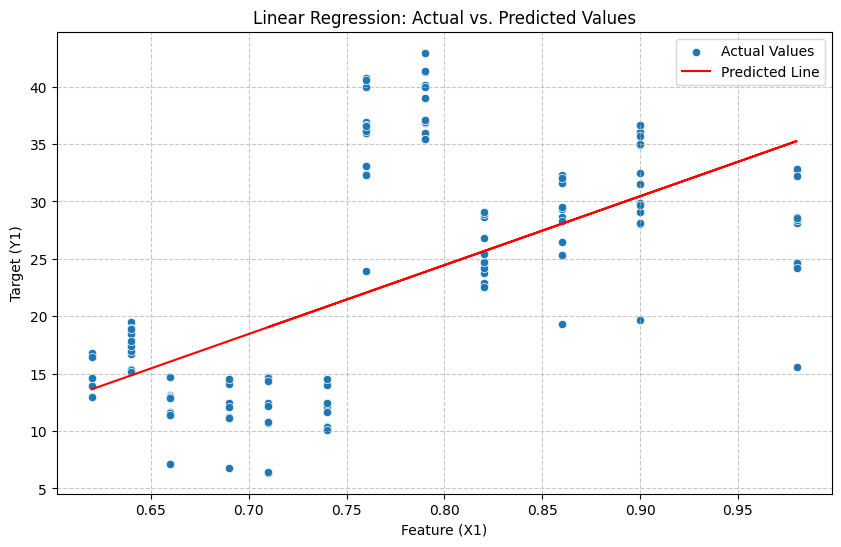

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/ENB2012_data.xlsx'
df_excel = pd.read_excel(file_path)

print(df_excel.head())
print(df_excel.shape)


# 1. Define features (X) and target (y) from the df_excel dataset

X = df_excel[['X1']]
y = df_excel['Y1']
print("\nFirst 5 rows of X:")
display(X.head())
print("\nFirst 5 values of y:")
display(y.head())

# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

print('____'*20)

# 3. Create a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. For a single feature model, coefficient is model.coef_[0]
print(f"Model Intercept: {model.intercept_:.2f}")
print(f"Model Coefficient: {model.coef_[0]:.2f}")

print('____'*20)

# 5. Calculate the correlation between 'Feature' (X1) and 'Target' (Y1)
correlation = X['X1'].corr(y)
print(f"Correlation between X1 and Y1: {correlation:.2f}")

X_train_ols = sm.add_constant(X_train)

print('____'*20)

# 6. Create and fit the OLS model
ols_model = sm.OLS(y_train, X_train_ols)
ols_results = ols_model.fit()

print(ols_results.summary())

print('____'*20)

# 7. Make predictions on the test set
y_pred = model.predict(X_test)

# 8. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# 9. Plot the results
fig = plt.figure(figsize=(10, 6))
# Use the selected feature column directly for plotting
sns.scatterplot(x=X_test['X1'], y=y_test, label='Actual Values')
plt.plot(X_test['X1'], y_pred, color='red', label='Predicted Line')
plt.title('Linear Regression: Actual vs. Predicted Values')
plt.xlabel('Feature (X1)')
plt.ylabel('Target (Y1)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Logistics regression
B)   implement the Same for Logistics regression as well .


Logistic Regression - Classification Problem:
Features shape: (768, 8)
Target shape: (768,)
Target distribution:
Y1
0    384
1    384
Name: count, dtype: int64
________________________________________________________________________________
Training set size for Logistic Regression: 614
Testing set size for Logistic Regression: 154
________________________________________________________________________________
Logistic Regression Model Coefficients:
X1: -0.38
X2: -0.02
X3: 0.04
X4: -0.03
X5: 0.70
X6: -0.01
X7: 2.04
X8: 0.39
Intercept: -0.19
________________________________________________________________________________
Logistic Regression Accuracy: 0.98

Confusion Matrix:
 [[76  1]
 [ 2 75]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        77
           1       0.99      0.97      0.98        77

    accuracy                           0.98       154
   macro avg       0.98      0.98      0.98       154


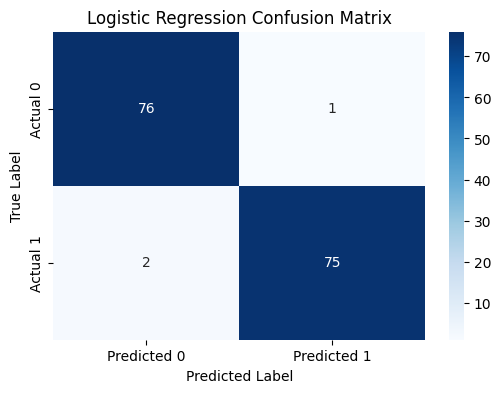

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Define features (X) and create a binary target (y) for Logistic Regression

features = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
X_log = df_excel[features]
y_log_median = df_excel['Y1'].median()
y_log = (df_excel['Y1'] > y_log_median).astype(int) # 1 if above median, 0 otherwise

print("Logistic Regression - Classification Problem:")
print(f"Features shape: {X_log.shape}")
print(f"Target shape: {y_log.shape}")
print(f"Target distribution:\n{y_log.value_counts()}")

print('____'*20)

# 2. Split the data into training and testing sets
X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(X_log, y_log, test_size=0.2, random_state=42, stratify=y_log)

print(f"Training set size for Logistic Regression: {X_log_train.shape[0]}")
print(f"Testing set size for Logistic Regression: {X_log_test.shape[0]}")

print('____'*20)

# 3. Model Training
# Using 'liblinear' solver for small datasets and 'lbfgs' is generally good for larger ones.

log_model = LogisticRegression(random_state=42, solver='liblinear')
log_model.fit(X_log_train, y_log_train)

print("Logistic Regression Model Coefficients:")
for feature, coef in zip(features, log_model.coef_[0]):
    print(f"{feature}: {coef:.2f}")
print(f"Intercept: {log_model.intercept_[0]:.2f}")

print('____'*20)

# 4. Model Evaluation
# Make predictions on the test set
y_log_pred = log_model.predict(X_log_test)
accuracy = accuracy_score(y_log_test, y_log_pred)
conf_matrix = confusion_matrix(y_log_test, y_log_pred)
class_report = classification_report(y_log_test, y_log_pred)

print(f"Logistic Regression Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

# Optional: Visualize Confusion Matrix

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## K-Nearest Neighbors (KNN)

C)   Use the same dataset and analyse how its working on KNN . Perform all Calculations (Euclidean,Manhattan ) using appropriate ML Frameworks.

KNN Classification - Re-using Data Split:
Training features shape: (614, 8)
Testing features shape: (154, 8)
Training target shape: (614,)
Testing target shape: (154,)
________________________________________________________________________________
KNN Model Trained.
________________________________________________________________________________
KNN Accuracy: 0.98

Confusion Matrix (KNN):
 [[76  1]
 [ 2 75]]

Classification Report (KNN):
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        77
           1       0.99      0.97      0.98        77

    accuracy                           0.98       154
   macro avg       0.98      0.98      0.98       154
weighted avg       0.98      0.98      0.98       154


--- KNN with Euclidean Distance ---
KNN Model (Euclidean) Trained.
KNN (Euclidean) Accuracy: 0.98

Classification Report (Euclidean):
               precision    recall  f1-score   support

           0       0.97      0.99     

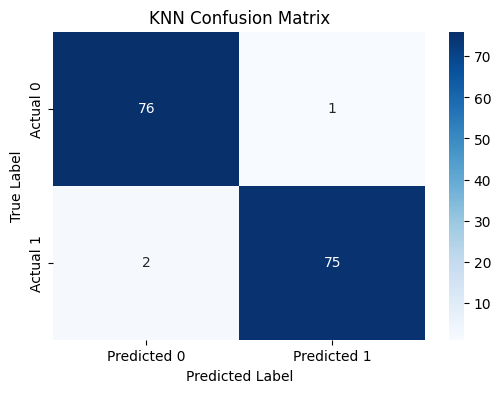

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. features (X_log) and binary target (y_log) from Logistic Regression

print("KNN Classification - Re-using Data Split:")
print(f"Training features shape: {X_log_train.shape}")
print(f"Testing features shape: {X_log_test.shape}")
print(f"Training target shape: {y_log_train.shape}")
print(f"Testing target shape: {y_log_test.shape}")

print('____'*20)

# 3. Model Training
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_log_train, y_log_train)
print("KNN Model Trained.")

print('____'*20)

# 4. Model Evaluation
# Make predictions on the test set
y_knn_pred = knn.predict(X_log_test)

# Evaluate the model
accuracy_knn = accuracy_score(y_log_test, y_knn_pred)
conf_matrix_knn = confusion_matrix(y_log_test, y_knn_pred)
class_report_knn = classification_report(y_log_test, y_knn_pred)

print(f"KNN Accuracy: {accuracy_knn:.2f}")
print("\nConfusion Matrix (KNN):\n", conf_matrix_knn)
print("\nClassification Report (KNN):\n", class_report_knn)

print("\n--- KNN with Euclidean Distance ---")
# 1. Initialize and train KNN model with Euclidean distance
knn_euclidean = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_euclidean.fit(X_log_train, y_log_train)
print("KNN Model (Euclidean) Trained.")

# 2. Make predictions and evaluate
y_pred_euclidean = knn_euclidean.predict(X_log_test)

accuracy_euclidean = accuracy_score(y_log_test, y_pred_euclidean)
conf_matrix_euclidean = confusion_matrix(y_log_test, y_pred_euclidean)
class_report_euclidean = classification_report(y_log_test, y_pred_euclidean)

print(f"KNN (Euclidean) Accuracy: {accuracy_euclidean:.2f}")
print("\nClassification Report (Euclidean):\n", class_report_euclidean)


print("\n--- KNN with Manhattan Distance ---")
# 3. Initialize and train KNN model with Manhattan distance
knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(X_log_train, y_log_train)
print("KNN Model (Manhattan) Trained.")

# 4. Make predictions and evaluate
y_pred_manhattan = knn_manhattan.predict(X_log_test)

accuracy_manhattan = accuracy_score(y_log_test, y_pred_manhattan)
conf_matrix_manhattan = confusion_matrix(y_log_test, y_pred_manhattan)
class_report_manhattan = classification_report(y_log_test, y_pred_manhattan)

print(f"KNN (Manhattan) Accuracy: {accuracy_manhattan:.2f}")
print("\nClassification Report (Manhattan):\n", class_report_manhattan)

# Visualize Confusion Matrix for KNN
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# SVM (Support Vector Machine)

D)  Take a new dataset and work on SVM . All kernel functions must be included  
while model building (Linear,polynomial,Radial based and sigmoid)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# 1. Define datas first & load
datas = ['sepal length','sepal width','petal length','petal width','class']
df = pd.read_csv('/content/iris.data', sep=',', names=datas)

print('\nOriginal class Distribution:')
print(df['class'].value_counts())

print(df['class'])

# 2. Find the total missing values
print(f'Total missing values: {df.isnull().sum().sum()}')

print('____'*20)

# 3. Using Encode categorical 'class' labels to numerical values
label_encoder = LabelEncoder()
df['class'] = label_encoder.fit_transform(df['class'])


print('\nNew class Distribution:')
print(df['class'].value_counts())
# 4. Display the mapping
print('\nClass Label Mapping:')
for i, name in enumerate(label_encoder.classes_):
    print(f'{name} -> {i}')


Original class Distribution:
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64
0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: class, Length: 150, dtype: object
Total missing values: 0
________________________________________________________________________________

New class Distribution:
class
0    50
1    50
2    50
Name: count, dtype: int64

Class Label Mapping:
Iris-setosa -> 0
Iris-versicolor -> 1
Iris-virginica -> 2


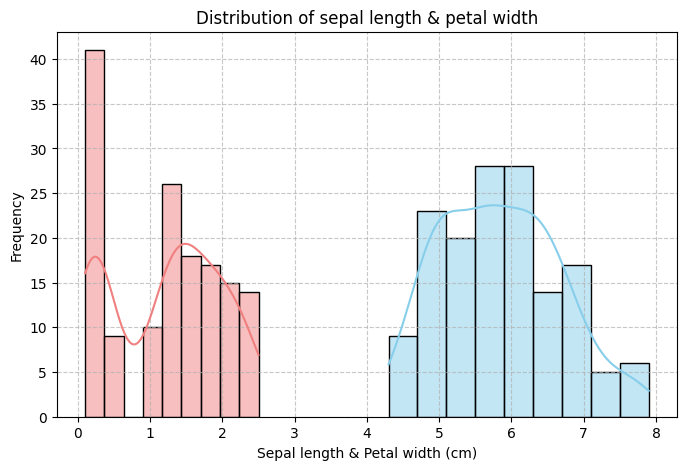

In [ ]:
# 5. Visualize the distribution of 'sepal length'&'petal width'
plt.figure(figsize=(8, 5))
# Sepal length
sns.histplot(df['sepal length'], kde=True, color='skyblue')
# Petal width
sns.histplot(df['petal width'], kde=True, color='lightcoral')
plt.title('Distribution of sepal length & petal width')
plt.xlabel('Sepal length & Petal width (cm)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# 5. Using drop funtion convert class into 1 & 0

X = df.drop('class', axis=1)
y = df['class']
print(df)

     sepal length  sepal width  petal length  petal width  class
0             5.1          3.5           1.4          0.2      0
1             4.9          3.0           1.4          0.2      0
2             4.7          3.2           1.3          0.2      0
3             4.6          3.1           1.5          0.2      0
4             5.0          3.6           1.4          0.2      0
..            ...          ...           ...          ...    ...
145           6.7          3.0           5.2          2.3      2
146           6.3          2.5           5.0          1.9      2
147           6.5          3.0           5.2          2.0      2
148           6.2          3.4           5.4          2.3      2
149           5.9          3.0           5.1          1.8      2

[150 rows x 5 columns]


In [ ]:
# 80% Training, 20% Testing with stratification to ensure balanced target class cuts

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training Features Vector Shape: {X_train.shape}')
print(f'Training Target Vector Shape: {y_train.shape}')
print(f'Testing Features Vector Shape: {X_test.shape}')
print(f'Testing Target Vector Shape: {y_test.shape}')

print('____'*20)

# Feature scaling AFTER split exlicitly guards against structual Data leakage

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to clean structured dataframes

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(X_train_scaled)
print(X_test_scaled)

Training Features Vector Shape: (120, 4)
Training Target Vector Shape: (120,)
Testing Features Vector Shape: (30, 4)
Testing Target Vector Shape: (30,)
________________________________________________________________________________
     sepal length  sepal width  petal length  petal width
0       -1.721568    -0.324840     -1.347036    -1.320168
1       -1.124492    -1.226129      0.414290     0.651867
2        1.144395    -0.550162      0.584741     0.257460
3       -1.124492     0.125805     -1.290219    -1.451638
4       -0.408002    -1.226129      0.130206     0.125991
..            ...          ...           ...          ...
115     -1.124492     0.125805     -1.290219    -1.451638
116     -1.363322     0.351127     -1.403853    -1.320168
117     -0.408002     2.604352     -1.347036    -1.320168
118      1.263810     0.125805      0.641558     0.388929
119     -1.482738     0.125805     -1.290219    -1.320168

[120 rows x 4 columns]
    sepal length  sepal width  petal length  pe

In [ ]:
# 6. Define all 4 baseline core kernels for testing comparison

kernels = {
    'linear':SVC(kernel='linear', C=1.0, random_state=42),
    'RBF':SVC(kernel='rbf', C=1.0, gamma=0.1, random_state=42),
    'poly':SVC(kernel='poly', C=1.0, degree=3, random_state=42),
    'sigmoid':SVC(kernel='sigmoid', C=1.0, gamma=0.1, random_state=42)
}

# Iterate , train , and test all 4 baseline options
kernel_benchmarks = {}
for name, model in kernels.items():
     model.fit(X_train_scaled, y_train)
     predictions = model.predict(X_test_scaled)
     acc = accuracy_score(y_test, predictions)
     kernel_benchmarks[name] = acc
     print(f'Baseline {name} accuracy: {acc:.4f}({acc*100:.2f}%)')

print('____'*20)

# 7. Build a dataframe summary overview of the results
summary_df = pd.DataFrame(list(kernel_benchmarks.items()), columns=['Kernel', 'Accuracy'])
print(summary_df.to_string(index=False))



Baseline linear accuracy: 1.0000(100.00%)
Baseline RBF accuracy: 0.9667(96.67%)
Baseline poly accuracy: 0.9000(90.00%)
Baseline sigmoid accuracy: 0.9333(93.33%)
________________________________________________________________________________
 Kernel  Accuracy
 linear  1.000000
    RBF  0.966667
   poly  0.900000
sigmoid  0.933333


In [ ]:
# 8. Identify which baseline won the initial test round
best_baseline_kernel = max(kernel_benchmarks, key=kernel_benchmarks.get)
print(f'\n Top performing architecture Chosen for optimization tuning: {best_baseline_kernel} ')


 Top performing architecture Chosen for optimization tuning: linear 


In [ ]:
# 9. Hyperparameter Tuning with GridSearchCV (Linear SVC)

param_grid = {
    'C' : [0.1, 1, 10, 50],
    'kernel' : ['linear','rbf','poly'],
    'gamma' :['scale','auto'],
    'degree' :[2,3]
}
print('Executing GridSearchCV across parameter combinations...')
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print('___'*30)

print(f'Optimal Hyperparameter Structures picked: {grid_search.best_params_}')
final_optimized_model = grid_search.best_estimator_
print(grid_search)

print('Best Parameters:', grid_search.best_params_)
print('Best Accuracy:', grid_search.best_score_)

Executing GridSearchCV across parameter combinations...
__________________________________________________________________________________________
Optimal Hyperparameter Structures picked: {'C': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 50], 'degree': [2, 3],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy')
Best Parameters: {'C': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
Best Accuracy: 0.975


In [ ]:
# 10. Final test for Accuracy

print(f'\n Final Tuned Architecture Test Accuracy: {final_optimized_model.score(X_test_scaled, y_test):.4f}')


 Final Tuned Architecture Test Accuracy: 0.9333


In [ ]:
# 11. Confusion Matrix for the Final Optimized SVC Model (Iris Dataset)

y_pred_final = final_optimized_model.predict(X_test_scaled)

print('\n final Detailed Classfication Report:')
print(classification_report(y_test, y_pred_final, target_names=label_encoder.classes_))



 final Detailed Classfication Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



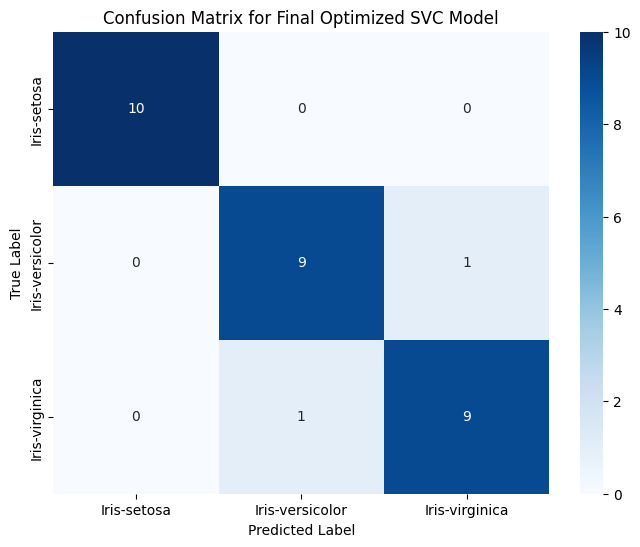


Final Confusion Matrix
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


In [ ]:
# 12. Calculate the confusion matrix for the final optimized SVC model
final_confusion_matrix = confusion_matrix(y_test, y_pred_final)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(final_confusion_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Final Optimized SVC Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
textcm = confusion_matrix(y_test, y_pred_final)
print('\nFinal Confusion Matrix')
print(textcm)

In [ ]:
# 13. joblib to files

joblib.dump(final_optimized_model, 'optimized_heart_svm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print('All components written out to system files successfully')

All components written out to system files successfully


# Decision Tree on UCI ML Heart Disease

E) Take a new dataset and work on Decision Trees . All functions must be included while model building.(Entropy,Gini,Information Gain)

In [ ]:

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt


import os

Head = ['buying','maint','doors','persons','lug_boot','safety','class']

dataframe = pd.read_csv('/content/car.data', header=None)

# Assign custom header

dataframe.columns = Head
dataframe.head()



,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [ ]:
dataframe.describe()
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=17, max_depth=3, min_samples_leaf=2)
tree.fit(X=X_train, y=y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=2, random_state=17)

/tmp/ipykernel_913/3466212287.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=dataframe, palette='viridis')


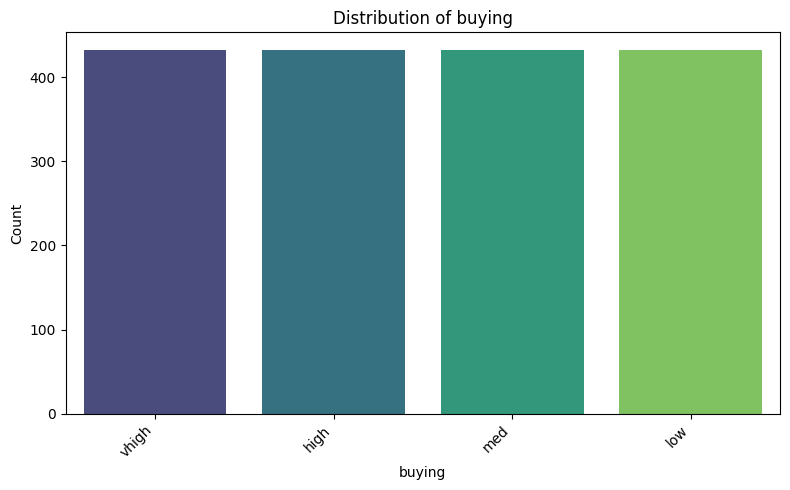

/tmp/ipykernel_913/3466212287.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=dataframe, palette='viridis')


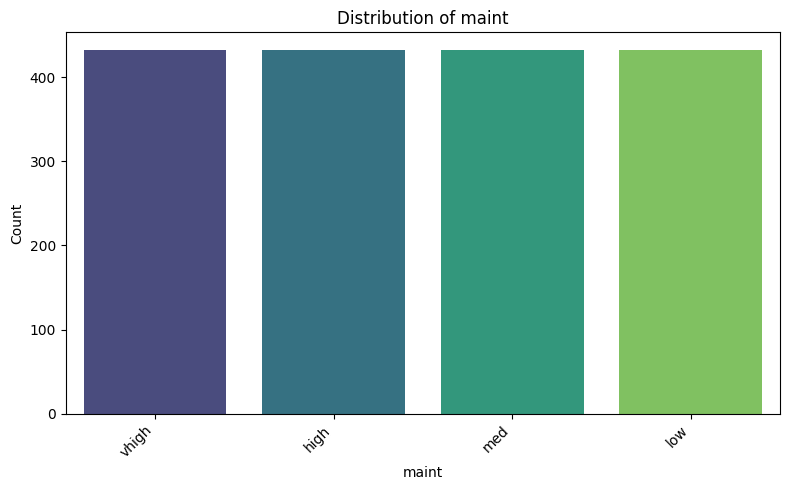

/tmp/ipykernel_913/3466212287.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=dataframe, palette='viridis')


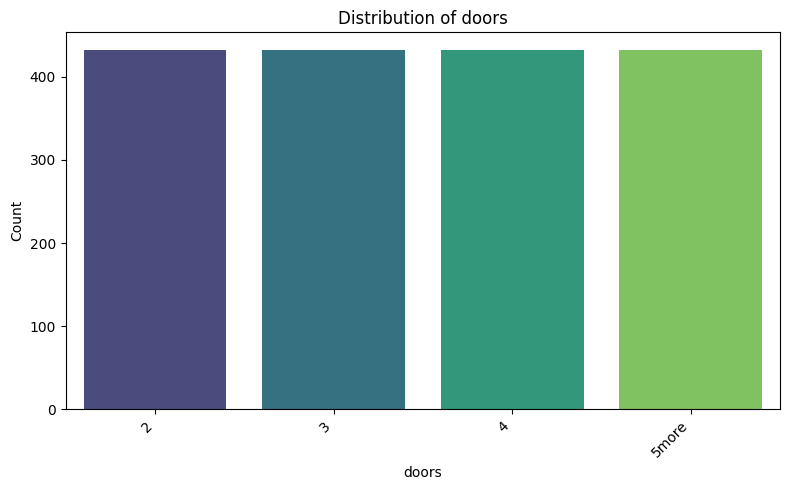

/tmp/ipykernel_913/3466212287.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=dataframe, palette='viridis')


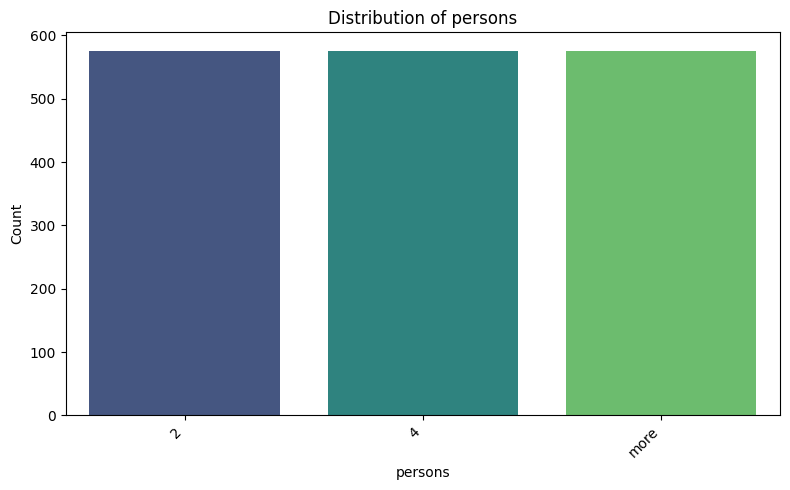

/tmp/ipykernel_913/3466212287.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=dataframe, palette='viridis')


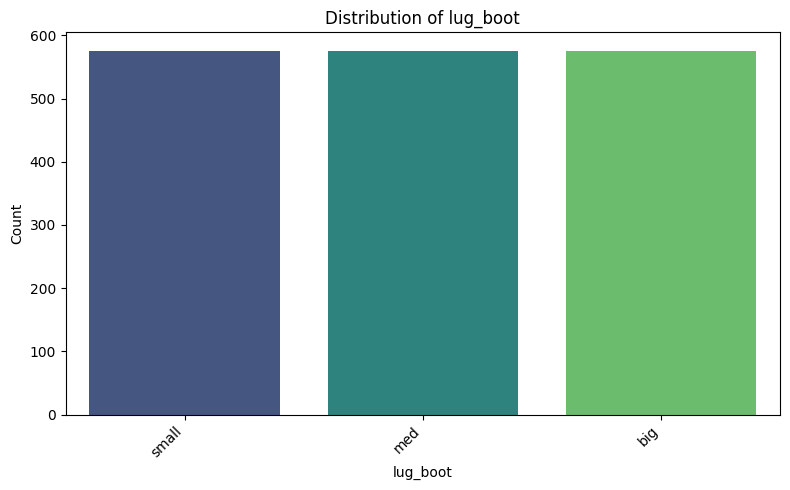

/tmp/ipykernel_913/3466212287.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=dataframe, palette='viridis')


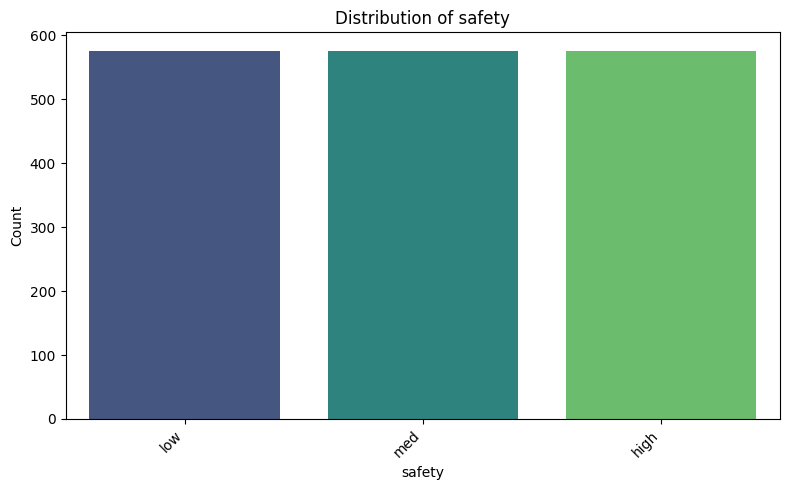

/tmp/ipykernel_913/3466212287.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=dataframe, palette='viridis')


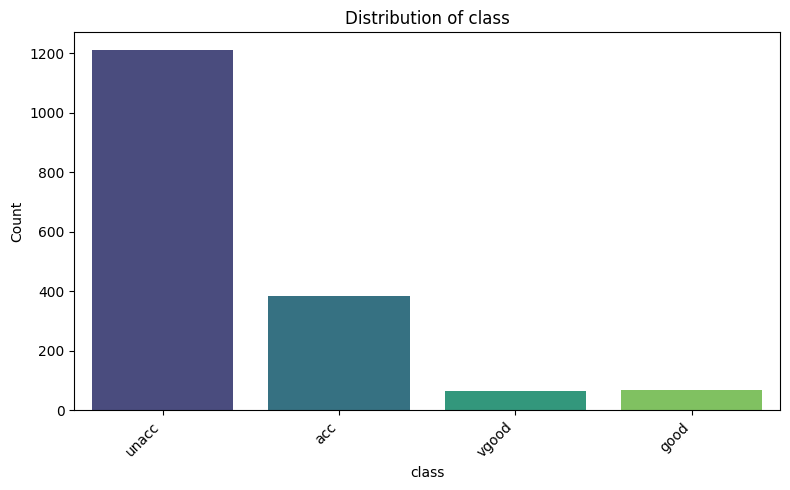

In [ ]:
plt.rcParams['figure.figsize'] = (20,8)
# Plot distributions for all categorical columns using countplots
for column in dataframe.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=column, data=dataframe, palette='viridis')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
y = dataframe['class']
dataframe.drop('class', axis=1,inplace=True)

In [ ]:
# Using One-hot encode the categorical features in X
X = pd.get_dummies(dataframe, drop_first=True)

print("Shape of feature matrix X after one-hot encoding:", X.shape)
print("First 5 rows of X:")
display(X.head())

Shape of feature matrix X after one-hot encoding: (1728, 15)
First 5 rows of X:


,buying_low,buying_med,buying_vhigh,maint_low,maint_med,maint_vhigh,doors_3,doors_4,doors_5more,persons_4,persons_more,lug_boot_med,lug_boot_small,safety_low,safety_med
0,False,False,True,False,False,True,False,False,False,False,False,False,True,True,False
1,False,False,True,False,False,True,False,False,False,False,False,False,True,False,True
2,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False
3,False,False,True,False,False,True,False,False,False,False,False,True,False,True,False
4,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1382, 15)
X_test shape: (346, 15)
y_train shape: (1382,)
y_test shape: (346,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier with entropy criterion
dtc_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)

# Train the model
dtc_entropy.fit(X_train, y_train)

print("Decision Tree Classifier (Entropy) trained successfully.")

Decision Tree Classifier (Entropy) trained successfully.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the Decision Tree Classifier with entropy (information gain) criterion
dtc_information_gain = DecisionTreeClassifier(criterion='entropy', random_state=42)

# Train the model
dtc_information_gain.fit(X_train, y_train)

print("Decision Tree Classifier (Entropy/Information Gain) trained successfully.")

# Make predictions on the test set
y_pred_information_gain = dtc_information_gain.predict(X_test)

# Evaluate the model
print("\n--- Decision Tree Classifier (Entropy/Information Gain) Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_information_gain):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_information_gain))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_information_gain))

Decision Tree Classifier (Entropy/Information Gain) trained successfully.

--- Decision Tree Classifier (Entropy/Information Gain) Evaluation ---
Accuracy: 0.9220

Classification Report:
               precision    recall  f1-score   support

         acc       0.82      0.90      0.86        77
        good       0.75      0.43      0.55        14
       unacc       0.96      0.97      0.96       242
       vgood       1.00      0.77      0.87        13

    accuracy                           0.92       346
   macro avg       0.88      0.77      0.81       346
weighted avg       0.92      0.92      0.92       346


Confusion Matrix:
 [[ 69   0   8   0]
 [  6   6   2   0]
 [  8   0 234   0]
 [  1   2   0  10]]


In [ ]:
# Initialize the Decision Tree Classifier with gini criterion
dtc_gini = DecisionTreeClassifier(criterion='gini', random_state=42)

# Train the model
dtc_gini.fit(X_train, y_train)

print("Decision Tree Classifier (Gini) trained successfully.")

# Make predictions on the test set
y_pred_gini = dtc_gini.predict(X_test)

# Evaluate the model
print("\n--- Decision Tree Classifier (Gini) Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gini):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_gini))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gini))

Decision Tree Classifier (Gini) trained successfully.

--- Decision Tree Classifier (Gini) Evaluation ---
Accuracy: 0.9104

Classification Report:
               precision    recall  f1-score   support

         acc       0.82      0.82      0.82        77
        good       0.50      0.29      0.36        14
       unacc       0.95      0.98      0.97       242
       vgood       1.00      0.77      0.87        13

    accuracy                           0.91       346
   macro avg       0.82      0.71      0.75       346
weighted avg       0.90      0.91      0.90       346


Confusion Matrix:
 [[ 63   2  12   0]
 [  9   4   1   0]
 [  4   0 238   0]
 [  1   2   0  10]]


# What is Pruning?


**Pruning** is a technique used in machine learning, particularly with decision trees, to reduce the size of the tree by removing sections of the tree that are less relevant or redundant. The primary goals of pruning are:

1.  **Reduce Overfitting**: Overgrown trees can capture noise in the training data, leading to poor generalization on unseen data. Pruning helps mitigate this.
2.  **Improve Interpretability**: Smaller trees are easier to understand and visualize.
3.  **Reduce Computational Cost**: Smaller trees require less computation for prediction.

There are two main types of pruning:

#### 1. Forward Pruning (Pre-pruning)

**Forward pruning**, also known as **pre-pruning**, involves stopping the tree's growth early during the training phase. Instead of building a full tree and then cutting it back, pre-pruning sets constraints on the tree's growth *before* it becomes fully grown. The tree building process stops when certain criteria are met.

**Common criteria for forward pruning:**
*   **Maximum depth (`max_depth`)**: Limits the maximum number of levels in the tree.
*   **Minimum samples per leaf (`min_samples_leaf`)**: Requires a minimum number of samples for a node to be split.
*   **Minimum samples for a split (`min_samples_split`)**: Requires a minimum number of samples in a node to consider splitting it.
*   **Maximum features to consider for best split (`max_features`)**: Limits the number of features to consider when looking for the best split.

**Pros:** Simpler and faster to implement as it avoids building a complex tree initially.
**Cons:** Might stop the growth too early, missing potentially important splits further down the tree (greedy approach).

#### 2. Backward Pruning (Post-pruning)

**Backward pruning**, also known as **post-pruning**, involves growing the decision tree to its full extent (or until a certain deep level) and then removing branches or nodes that provide little predictive power or contribute to overfitting. The algorithm first constructs the complete tree and then evaluates subtrees for removal.

**Common techniques for backward pruning:**
*   **Reduced Error Pruning**: Uses a validation set to evaluate the impact of removing each node.
*   **Cost-Complexity Pruning (Weakest Link Pruning)**: Calculates a complexity parameter (`alpha`) for each node and iteratively prunes the node with the smallest `alpha` until the desired complexity is reached or the performance on a validation set no longer improves. In scikit-learn, this is implemented via the `ccp_alpha` parameter.

**Pros:** Often leads to better-performing trees than pre-pruning because it considers the full tree structure before making pruning decisions.
**Cons:** More computationally expensive as it requires building the full tree first.




In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd

# Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

print("Dataset loaded successfully. First 5 rows of features:")
display(X.head())
print("Target variable distribution:")
display(y.value_counts())


Dataset loaded successfully. First 5 rows of features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Target variable distribution:


,count
0,50
1,50
2,50


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Testing set size: {X_test.shape[0]} samples')


Training set size: 105 samples
Testing set size: 45 samples


### 1. Forward Pruning (Pre-pruning)

For forward pruning, we'll use a Decision Tree Classifier and set parameters like `max_depth` or `min_samples_leaf` to stop the tree's growth during training. Here, we'll limit the `max_depth` to demonstrate its effect.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Unpruned Tree (for comparison)
print("\n--- Training Unpruned Decision Tree ---")
unpruned_tree = DecisionTreeClassifier(random_state=42)
unpruned_tree.fit(X_train, y_train)
unpruned_predictions = unpruned_tree.predict(X_test)
unpruned_accuracy = accuracy_score(y_test, unpruned_predictions)
print(f"Unpruned Tree Test Accuracy: {unpruned_accuracy:.4f}")

# 2. Forward Pruned Tree (using max_depth)
print("\n--- Training Forward Pruned Decision Tree (max_depth=3) ---")
forward_pruned_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
forward_pruned_tree.fit(X_train, y_train)
forward_pruned_predictions = forward_pruned_tree.predict(X_test)
forward_pruned_accuracy = accuracy_score(y_test, forward_pruned_predictions)
print(f"Forward Pruned Tree Test Accuracy (max_depth=3): {forward_pruned_accuracy:.4f}")

# 3. Another Forward Pruned Tree (using min_samples_leaf)
print("\n--- Training Forward Pruned Decision Tree (min_samples_leaf=5) ---")
forward_pruned_tree_leaf = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
forward_pruned_tree_leaf.fit(X_train, y_train)
forward_pruned_predictions_leaf = forward_pruned_tree_leaf.predict(X_test)
forward_pruned_accuracy_leaf = accuracy_score(y_test, forward_pruned_predictions_leaf)
print(f"Forward Pruned Tree Test Accuracy (min_samples_leaf=5): {forward_pruned_accuracy_leaf:.4f}")



--- Training Unpruned Decision Tree ---
Unpruned Tree Test Accuracy: 0.9333

--- Training Forward Pruned Decision Tree (max_depth=3) ---
Forward Pruned Tree Test Accuracy (max_depth=3): 0.9778

--- Training Forward Pruned Decision Tree (min_samples_leaf=5) ---
Forward Pruned Tree Test Accuracy (min_samples_leaf=5): 0.8889


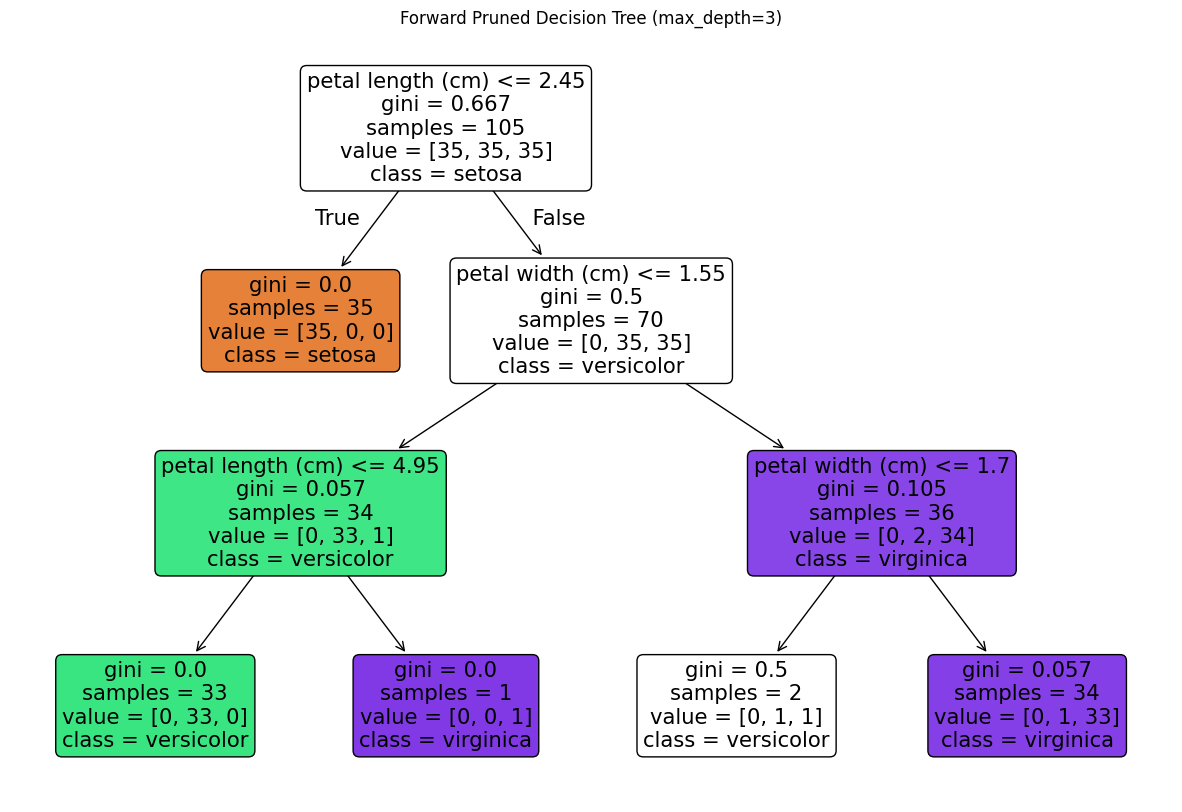

The unpruned tree would be much larger and harder to visualize, but here's the compact forward-pruned version.


In [ ]:
# Visualize the Forward Pruned Tree (max_depth=3)
plt.figure(figsize=(15, 10))
plot_tree(forward_pruned_tree, feature_names=X.columns, class_names=iris.target_names, filled=True, rounded=True)
plt.title("Forward Pruned Decision Tree (max_depth=3)")
plt.show()

print(f"The unpruned tree would be much larger and harder to visualize, but here's the compact forward-pruned version.")


As you can see, by setting `max_depth` or `min_samples_leaf`, we directly control the complexity of the tree during its construction. Next, we will explore **Backward Pruning**.

### 2. Backward Pruning (Post-pruning) - Cost-Complexity Pruning

Backward pruning involves growing the tree to its full extent and then pruning it back. Scikit-learn implements this primarily through **Cost-Complexity Pruning (CCP)**, which uses a parameter called `ccp_alpha`.

`ccp_alpha` is a non-negative floating point value. The smallest `ccp_alpha` value that results in a pruned tree is 0. With increasing `ccp_alpha`, more nodes are pruned, and the tree becomes simpler. We can find the optimal `ccp_alpha` by cross-validation.

Available ccp_alphas for pruning:
[0.     0.009  0.0185 0.2789 0.3333]


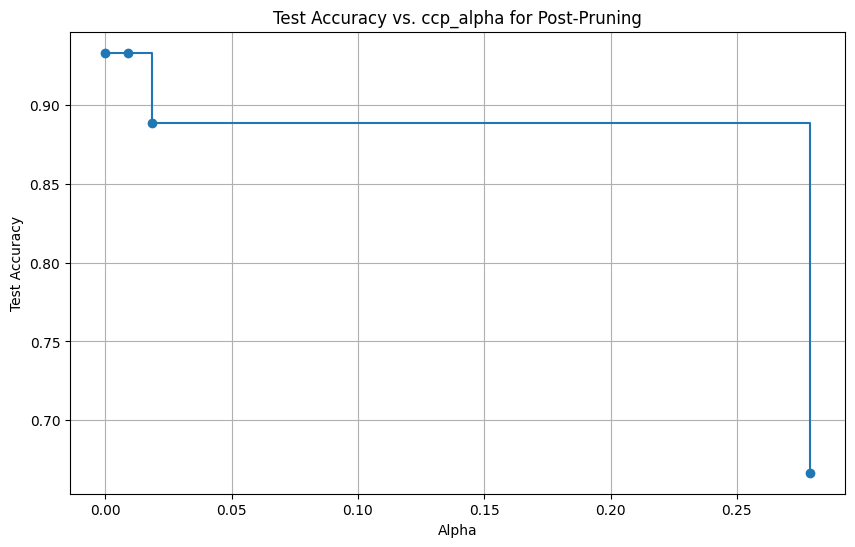


Optimal ccp_alpha found: 0.0000
Max Test Accuracy with optimal ccp_alpha: 0.9333

Backward Pruned Tree Test Accuracy (optimal ccp_alpha): 0.9333


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Train an unpruned tree to find its ccp_alphas
path = unpruned_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

print("Available ccp_alphas for pruning:")
print(np.round(ccp_alphas, 4))

# Filter out redundant alphas (can happen if some branches are pruned at the same alpha)
# ccp_alphas = np.unique(ccp_alphas)

# Train decision trees for each alpha and collect scores
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

# Evaluate the accuracy on the test set for each alpha
accuracy_scores = [accuracy_score(y_test, clf.predict(X_test)) for clf in clfs]

# Plot accuracy vs alpha
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas[:-1], accuracy_scores[:-1], marker='o', drawstyle="steps-post")
plt.xlabel("Alpha")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs. ccp_alpha for Post-Pruning")
plt.grid(True)
plt.show()

# Find the optimal ccp_alpha based on max accuracy
optimal_alpha_index = np.argmax(accuracy_scores[:-1])
optimal_ccp_alpha = ccp_alphas[optimal_alpha_index]

print(f"\nOptimal ccp_alpha found: {optimal_ccp_alpha:.4f}")
print(f"Max Test Accuracy with optimal ccp_alpha: {accuracy_scores[optimal_alpha_index]:.4f}")

# Train the final backward-pruned tree with the optimal ccp_alpha
backward_pruned_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=optimal_ccp_alpha)
backward_pruned_tree.fit(X_train, y_train)

print(f"\nBackward Pruned Tree Test Accuracy (optimal ccp_alpha): {accuracy_score(y_test, backward_pruned_tree.predict(X_test)):.4f}")


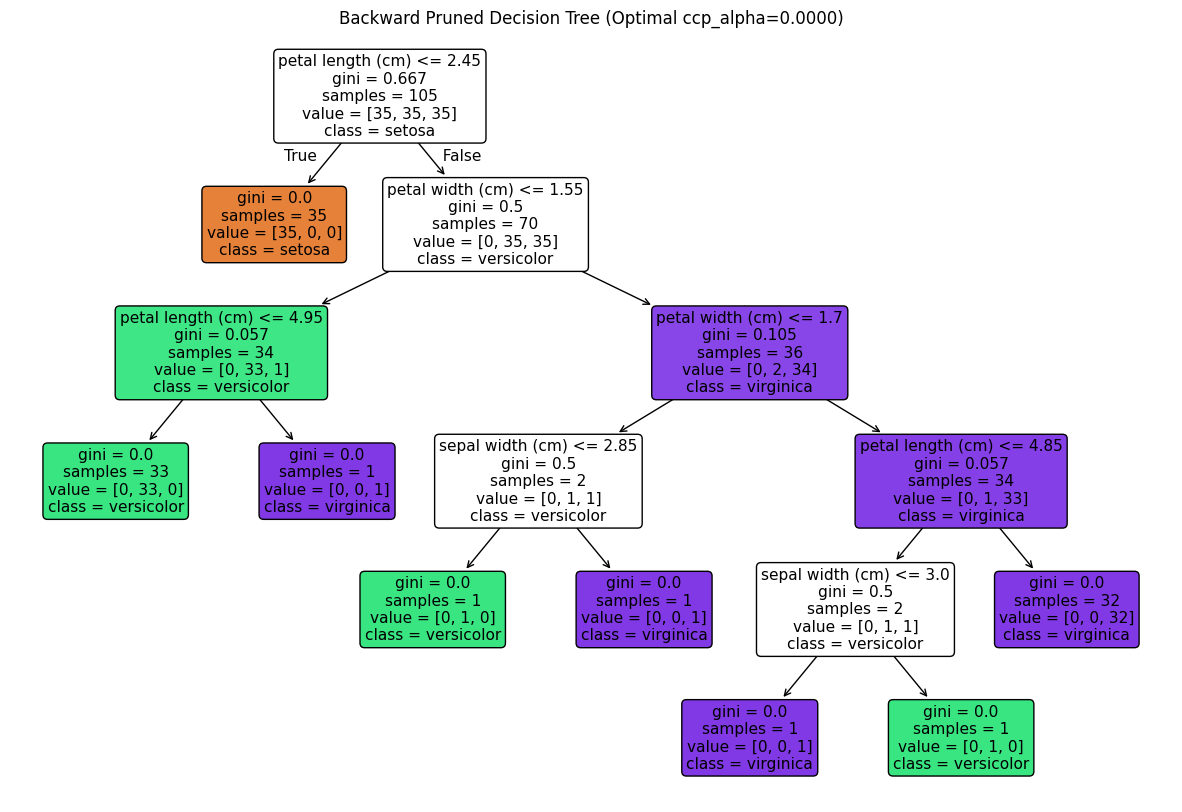

Comparing the sizes and complexities of the forward and backward pruned trees, as well as their accuracies, gives insight into which pruning strategy might be more effective for a given dataset.


In [ ]:
from sklearn.tree import plot_tree

# Visualize the Backward Pruned Tree (with optimal ccp_alpha)
plt.figure(figsize=(15, 10))
plot_tree(backward_pruned_tree, feature_names=X.columns, class_names=iris.target_names, filled=True, rounded=True)
plt.title(f"Backward Pruned Decision Tree (Optimal ccp_alpha={optimal_ccp_alpha:.4f})")
plt.show()

print("Comparing the sizes and complexities of the forward and backward pruned trees, as well as their accuracies, gives insight into which pruning strategy might be more effective for a given dataset.")

Feature Importances Comparison:


,Feature,Forward Pruned (max_depth=3),Backward Pruned (optimal ccp_alpha)
2,petal length (cm),0.550877,0.541176
3,petal width (cm),0.449123,0.430252
1,sepal width (cm),0.000000,0.028571
0,sepal length (cm),0.000000,0.000000


/tmp/ipykernel_913/906071386.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Forward Pruned (max_depth=3)', y='Feature', data=importance_df_sorted, ax=axes[0], palette='viridis')
/tmp/ipykernel_913/906071386.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Backward Pruned (optimal ccp_alpha)', y='Feature', data=importance_df_sorted, ax=axes[1], palette='magma')


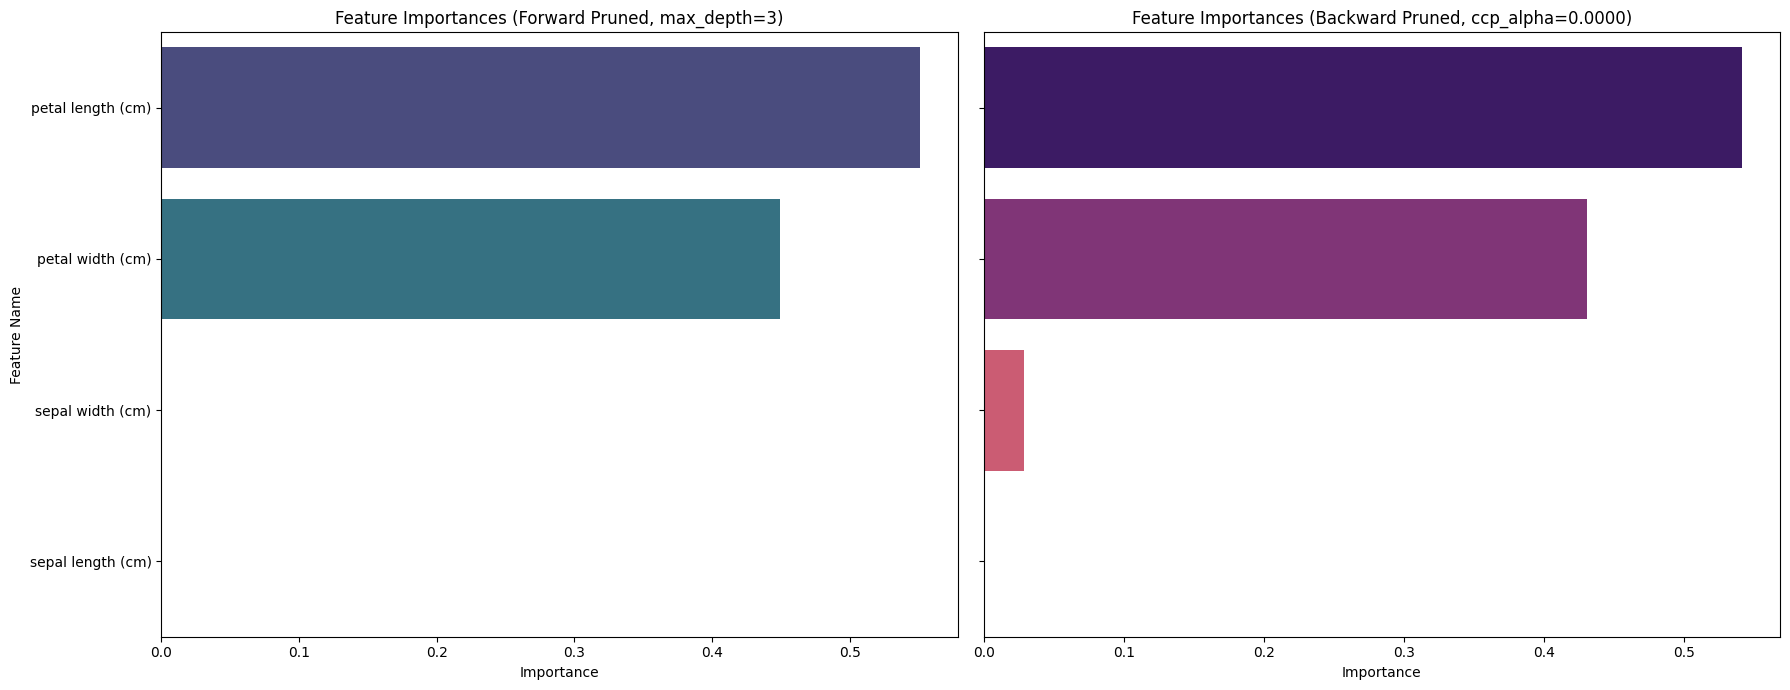

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the forward-pruned tree (max_depth=3)
forward_importances = forward_pruned_tree.feature_importances_

# Get feature importances from the backward-pruned tree (optimal ccp_alpha)
backward_importances = backward_pruned_tree.feature_importances_

# Create a DataFrame for better visualization and comparison
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Forward Pruned (max_depth=3)': forward_importances,
    'Backward Pruned (optimal ccp_alpha)': backward_importances
})

# Sort by importance for better readability (e.g., by forward pruned importance)
importance_df_sorted = importance_df.sort_values(by='Forward Pruned (max_depth=3)', ascending=False)

print("Feature Importances Comparison:")
display(importance_df_sorted)

# Visualize the feature importances
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Plot for Forward Pruned Tree
sns.barplot(x='Forward Pruned (max_depth=3)', y='Feature', data=importance_df_sorted, ax=axes[0], palette='viridis')
axes[0].set_title('Feature Importances (Forward Pruned, max_depth=3)')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Feature Name')

# Plot for Backward Pruned Tree
sns.barplot(x='Backward Pruned (optimal ccp_alpha)', y='Feature', data=importance_df_sorted, ax=axes[1], palette='magma')
axes[1].set_title(f'Feature Importances (Backward Pruned, ccp_alpha={optimal_ccp_alpha:.4f})')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('') # Remove y-label for the second plot as it's shared

plt.tight_layout()
plt.show()
